# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

Berekende massa water: 0.4721 kg
Geschat vermogen element: 44.46 Watt


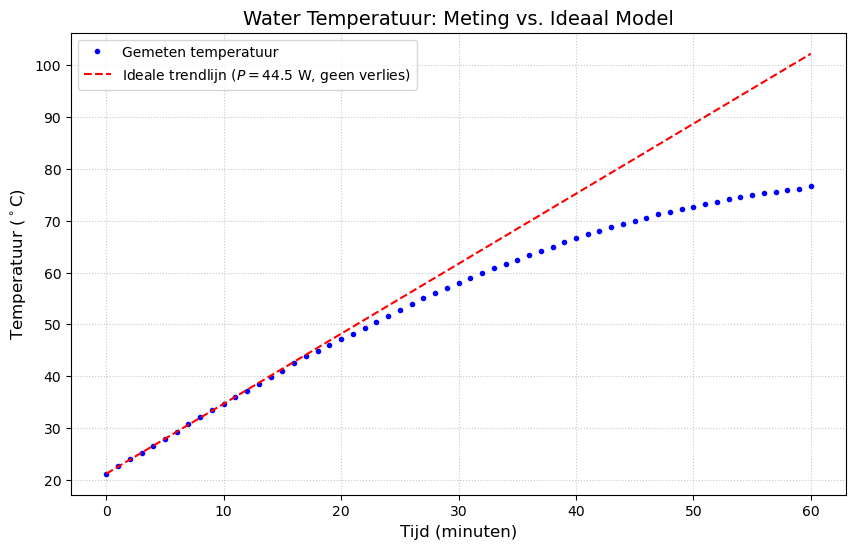

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# opdracht 1

# Constanten uit de opgave (omgezet naar kg)
m_maatbeker = 820.8 / 1000      # kg
m_start_totaal = 1292.9 / 1000  # kg
m_eind_totaal = 1274.9 / 1000   # kg

m_water_start = m_start_totaal - m_maatbeker
c_water = 4186  # Specifieke warmtecapaciteit water in J/(kg*K)

# 2. Data inladen
# Let op: de delimiter in het bestand is een puntkomma ';'
df = pd.read_csv('tempmetingen.csv', sep=';')
df.columns = ['tijd_min', 'temp_C'] # Kolomnamen opschonen

# 3. Vermogen (P) bepalen
# We kijken naar de eerste 10 minuten om het vermogen te schatten (Vóórdat warmteverlies naar de omgeving een grote rol gaat spelen)
t_start = df['tijd_min'].iloc[0] * 60  # naar seconden
t_10 = df['tijd_min'].iloc[10] * 60    # naar seconden
T_start = df['temp_C'].iloc[0]
T_10 = df['temp_C'].iloc[10]

# Delta T / Delta t (K/s)
opwarmsnelheid = (T_10 - T_start) / (t_10 - t_start)
# P = m * c * (dT/dt)
P_berekend = m_water_start * c_water * opwarmsnelheid

print(f"Berekende massa water: {m_water_start:.4f} kg")
print(f"Geschat vermogen element: {P_berekend:.2f} Watt")

# 4. Theoretische trendlijn berekenen
df['tijd_sec'] = df['tijd_min'] * 60
T0 = df['temp_C'].iloc[0]
df['temp_theo'] = T0 + (P_berekend * df['tijd_sec']) / (m_water_start * c_water)

# 5. Plot maken
plt.figure(figsize=(10, 6))

# Metingen
plt.plot(df['tijd_min'], df['temp_C'], 'b.', label='Gemeten temperatuur', markersize=6)

# Ideale trendlijn
plt.plot(df['tijd_min'], df['temp_theo'], 'r--', 
         label=f'Ideale trendlijn ($P = {P_berekend:.1f}$ W, geen verlies)')

# Opmaak
plt.title('Water Temperatuur: Meting vs. Ideaal Model', fontsize=14)
plt.xlabel('Tijd (minuten)', fontsize=12)
plt.ylabel('Temperatuur ($^\circ$C)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Opslaan en tonen
plt.savefig('temperatuur_analyse.png', dpi=300)
plt.show()

In [ ]:
# Opdracht 2: Energiebalans 
import pandas as pd

# 1. Constanten en gegevens
m_maatbeker = 820.8 / 1000      # kg
m_start_totaal = 1292.9 / 1000  # kg
m_eind_totaal = 1274.9 / 1000   # kg
c_water = 4186                  # J/(kg*K)
Lv = 2.26e6                     # Verdampingswarmte water in J/kg

m_water_start = m_start_totaal - m_maatbeker
m_water_eind = m_eind_totaal - m_maatbeker
m_verdwenen = m_water_start - m_water_eind

# 2. Data inladen
df = pd.read_csv('tempmetingen.csv', sep=';')
df.columns = ['tijd_min', 'temp_C']

# Bereken P op basis van de eerste 10 min (zoals in opdracht 1)
dt_sec = (df['tijd_min'].iloc[10] - df['tijd_min'].iloc[0]) * 60
dT = df['temp_C'].iloc[10] - df['temp_C'].iloc[0]
P = m_water_start * c_water * (dT / dt_sec)

# 3. Energieberekeningen
t_totaal_sec = df['tijd_min'].iloc[-1] * 60
Q_tot = P * t_totaal_sec

# Warmte nodig voor opwarming (Q = m * c * deltaT)
T_start = df['temp_C'].iloc[0]
T_eind = df['temp_C'].iloc[-1]
Q_warmte = m_water_start * c_water * (T_eind - T_start)

# Warmte nodig voor verdamping (Q = m * Lv)
Q_verdamp = m_verdwenen * Lv

Q_nuttig = Q_warmte + Q_verdamp
verlies = Q_tot - Q_nuttig

# 4. Resultaten printen
print(f"Energiebalans Resultaten")
print(f"Totaal toegevoegde energie (Q_tot):    {Q_tot/1000:>7.1f} kJ")
print(f"Energie voor opwarming (Q_warmte):     {Q_warmte/1000:>7.1f} kJ")
print(f"Energie voor verdamping (Q_verdamp):   {Q_verdamp/1000:>7.1f} kJ")


print(f"Totaal verklaard (Q_nuttig):           {Q_nuttig/1000:>7.1f} kJ")
print(f"Verschil (verlies/maatbeker):          {verlies/1000:>7.1f} kJ")
print(f"Rendement:                             {Q_nuttig/Q_tot:>7.1%}")

--- Energiebalans Resultaten ---
Totaal toegevoegde energie (Q_tot):      160.1 kJ
Energie voor opwarming (Q_warmte):       109.5 kJ
Energie voor verdamping (Q_verdamp):      40.7 kJ
Totaal verklaard (Q_nuttig):             150.2 kJ
Verschil (verlies/maatbeker):              9.9 kJ
Rendement:                               93.8%


## 3. Aanbevelingen voor verbetering van het experiment

Om het thermodynamische proces nauwkeuriger te beschrijven en de energiebalans sluitend te maken, kunnen de volgende verbeteringen worden doorgevoerd:

### 1. Minimaliseren en kwantificeren van warmteverliezen
* **Isolatie:** Gebruik een calorimeter of een dubbelwandige beker (zoals een thermoskan) om warmteverlies naar de omgeving via conductie en straling te minimaliseren.
* **Afdekken:** Gebruik een isolerende deksel. Dit vermindert niet alleen warmteverlies naar de lucht, maar beperkt ook ongecontroleerde verdamping, wat een grote onbekende factor is in de huidige energiebalans.

### 2. Nauwkeurigere bepaling van het toegevoegde vermogen ($P$)
* **Directe meting:** In plaats van het vermogen te schatten op basis van de eerste metingen, kunnen een **voltmeter** en **amperemeter** worden aangesloten op het verwarmingselement. Met $P = U \cdot I$ kan het werkelijke elektrische vermogen continu worden gemonitord.
* **Spanningsstabilisator:** Gebruik een gestabiliseerde voeding om fluctuaties in het vermogen te voorkomen.

### 3. Dynamische massameting
* **Continue weging:** Plaats de gehele opstelling (inclusief maatbeker en element) op een digitale bovenweger die verbonden is met de computer. Zo kan het verloop van de massa ($m$) over de tijd worden gevolgd. Hierdoor kan de energie die naar verdamping gaat ($Q_{verdamp}$) nauwkeuriger worden gekoppeld aan de temperatuur op dat moment.

### 4. Verbetering van de temperatuurmeting
* **Roeren:** Gebruik een magnetische roerder om een homogene temperatuur in het water te garanderen. Zonder roeren meet de thermometer mogelijk een lokale 'hotspot' nabij het element.
* **Sensorkalibratie:** Gebruik digitale temperatuursensoren (zoals een Pt100 of DS18B20) met een hogere resolutie en kortere reactietijd dan een analoge thermometer.

### 5. Rekening houden met de warmtecapaciteit van de beker
* **Water-equivalent:** Bepaal vooraf de warmtecapaciteit van de maatbeker zelf ($C_{beker}$). Een deel van de energie gaat namelijk in het glas zitten. Door dit mee te nemen in de formule $Q_{totaal} = (m_w \cdot c_w + C_{beker}) \cdot \Delta T$, wordt de theoretische trendlijn een stuk nauwkeuriger.